In [1]:
import torch
import numpy as np
from torch.autograd.functional import jacobian
from scipy.optimize import fsolve

import matplotlib.pyplot as plt

In [2]:
def generate_trilateration_data(true_pos, stations, noise_std=0.1):
    """
    Genere des mesures de distance bruitees.
    Args:
    true_pos: position reelle (array de dim n)
    stations: positions des stations (array m x n)
    noise_std: ecart-type du bruit sur les distances
    Returns:
    distances: mesures bruitees (array de dim m)
    """
    true_distances = np.linalg.norm(stations - true_pos, axis=1)
    noise = np.random.normal(0, noise_std, size=len(stations))
    distances = true_distances + noise
    return distances
def generate_gps_pseudoranges(true_pos, satellites, true_bias, noise_std=1.0):
    """
    Genere des pseudo-distances GPS avec biais d’horloge.
    Args:
    true_pos: position reelle (array 3D)
    satellites: positions des satellites (array m x 3)
    true_bias: biais d’horloge en metres (c * delta_t)
    noise_std: ecart-type du bruit
    2Returns:
    pseudoranges: pseudo-distances mesurees
    """
    true_ranges = np.linalg.norm(satellites - true_pos, axis=1)
    noise = np.random.normal(0, noise_std, size=len(satellites))
    pseudoranges = true_ranges + true_bias + noise
    return pseudoranges
# Exemple d’utilisation]
# Configuration 2D
stations = np.array([
[0, 0], [10, 0], [5, 8], [0, 6]
])
true_position = np.array([3.5, 4.2])
distances = generate_trilateration_data(
true_position, stations, noise_std=0.2
)
print("Stations:", stations)
print("Vraie position:", true_position)
print("Distances mesurees:", distances)

Stations: [[ 0  0]
 [10  0]
 [ 5  8]
 [ 0  6]]
Vraie position: [3.5 4.2]
Distances mesurees: [5.49102855 7.6537526  3.88655081 3.96797015]


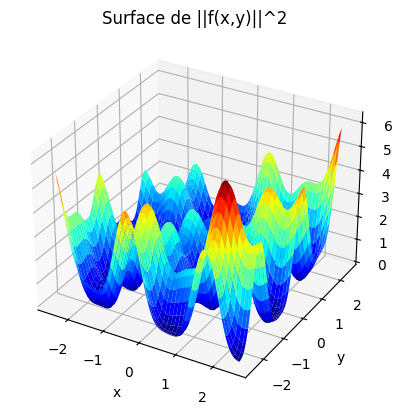

--- Test 1 ---
Point initial beta0 = [0.5 0.5]
Beta final = [-3.39746853 -1.31476709]
Convergence = True
Nombre d'itérations = 31
Norme du résidu final = 7.850462e-16
Norme du dernier pas = 2.448300e-12

--- Test 2 ---
Point initial beta0 = [1. 1.]
Beta final = [1.07433657 1.27109048]
Convergence = True
Nombre d'itérations = 5
Norme du résidu final = 3.747003e-16
Norme du dernier pas = 4.480520e-15

--- Test 3 ---
Point initial beta0 = [2. 2.]
Beta final = [2.02223752 1.71595349]
Convergence = True
Nombre d'itérations = 6
Norme du résidu final = 1.387779e-16
Norme du dernier pas = 2.522763e-13

--- Test 4 ---
Point initial beta0 = [-1.  1.]
Beta final = [-1.04290676  1.04290676]
Convergence = True
Nombre d'itérations = 3
Norme du résidu final = 2.870325e-16
Norme du dernier pas = 1.485528e-09

--- Test 5 ---
Point initial beta0 = [ 1. -1.]
Beta final = [ 0.85096102 -0.85096102]
Convergence = True
Nombre d'itérations = 4
Norme du résidu final = 3.140185e-16
Norme du dernier pas = 5.3431

In [3]:
import torch
from torch.autograd.functional import jacobian
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm


def gauss_newton(f, beta0, tol=1e-6, NitMax=1000, store_history=True):
    convergence = False

    t_beta = torch.tensor(beta0, dtype=torch.float64, requires_grad=True)

    beta_history = [t_beta.detach().clone()] if store_history else []
    pas_history = []
    r_history = []

    pas = None

    for i in range(NitMax):
        # Jacobienne du résidu
        Jr = jacobian(f, t_beta)

        with torch.no_grad():
            r = f(t_beta)         # vecteur résidu
            A = Jr.T @ Jr
            B = Jr.T @ r

            # Résolution du système normal
            # plus robuste que solve si A est mal conditionnée
            try:
                pas = torch.linalg.solve(A, B)
            except RuntimeError:
                pas = torch.linalg.pinv(A) @ B

            # Mise à jour
            t_beta -= pas

            if store_history:
                beta_history.append(t_beta.detach().clone())
                pas_history.append(pas.detach().clone())
                r_history.append(r.detach().clone())

            # Critère d'arrêt
            if torch.linalg.norm(pas) < tol:
                convergence = True
                break

    # Recalcul final
    Jr_final = jacobian(f, t_beta)
    with torch.no_grad():
        r_final = f(t_beta)
        A_final = Jr_final.T @ Jr_final

    return {
        "beta": t_beta.detach(),
        "iterations": i + 1,
        "convergence": convergence,
        "norme_du_dernier_pas": torch.linalg.norm(pas).item() if pas is not None else None,
        "f_norm": torch.linalg.norm(r_final).item(),
        "jacobian_final": Jr_final.detach().numpy(),
        "normal_matrix_final": A_final.detach().numpy(),
        "beta_history": [b.numpy() for b in beta_history] if store_history else None,
        "pas_history": [p.numpy() for p in pas_history] if store_history else None,
        "r_history": [r.numpy() for r in r_history] if store_history else None
    }


def etude_sensibilite_point_initial(f, liste_beta0, tol=1e-6, NitMax=1000):
    resultats = []

    for beta0 in liste_beta0:
        try:
            res = gauss_newton(f, beta0, tol=tol, NitMax=NitMax, store_history=False)

            resultats.append({
                "beta0": np.array(beta0),
                "beta_final": res["beta"].numpy(),
                "convergence": res["convergence"],
                "iterations": res["iterations"],
                "norme_residu_final": res["f_norm"],
                "norme_dernier_pas": res["norme_du_dernier_pas"]
            })

        except Exception as e:
            resultats.append({
                "beta0": np.array(beta0),
                "beta_final": None,
                "convergence": False,
                "iterations": None,
                "norme_residu_final": None,
                "norme_dernier_pas": None,
                "erreur": str(e)
            })

    return resultats


def afficher_etude_sensibilite(resultats):
    for k, res in enumerate(resultats):
        print(f"--- Test {k+1} ---")
        print(f"Point initial beta0 = {res['beta0']}")

        if res["beta_final"] is not None:
            print(f"Beta final = {res['beta_final']}")
            print(f"Convergence = {res['convergence']}")
            print(f"Nombre d'itérations = {res['iterations']}")
            print(f"Norme du résidu final = {res['norme_residu_final']:.6e}")
            print(f"Norme du dernier pas = {res['norme_dernier_pas']:.6e}")
        else:
            print("Échec de l'algorithme")
            print(f"Erreur : {res.get('erreur', 'inconnue')}")
        print()

def f(beta):
    x, y = beta[0], beta[1]
    return torch.stack([
        torch.sin(3*x) + 0.3*(y - 1),
        torch.sin(3*y) + 0.3*(x + 1)
    ])

def g(x, y):
    beta = torch.tensor([x, y], dtype=torch.float64)
    val = f(beta)
    return torch.sum(val**2).item()


# Grille
X = np.linspace(-2.5, 2.5, 200)
Y = np.linspace(-2.5, 2.5, 200)
X, Y = np.meshgrid(X, Y)

# Calcul
Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = g(X[i, j], Y[i, j])

# Surface
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap=cm.jet)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("||f(x,y)||^2")
ax.set_title("Surface de ||f(x,y)||^2")
plt.show()


liste_beta0 = [
    [0.5, 0.5],
    [1.0, 1.0],
    [2.0, 2.0],
    [-1.0, 1.0],
    [1.0, -1.0],
    [-2.0, -2.0]
]

resultats = etude_sensibilite_point_initial(f, liste_beta0, tol=1e-8, NitMax=100)
afficher_etude_sensibilite(resultats)

In [4]:
import matplotlib.pyplot as plt

# Génération de points initiaux aléatoires
def generer_points_aleatoires(n, xmin=-2.5, xmax=2.5):
    return [np.random.uniform(xmin, xmax, size=2) for _ in range(n)]


def tracer_convergence(f, liste_beta0, tol=1e-6, NitMax=50):
    plt.figure(figsize=(8, 6))

    # Grille pour contours
    X = np.linspace(-2.5, 2.5, 200)
    Y = np.linspace(-2.5, 2.5, 200)
    X, Y = np.meshgrid(X, Y)

    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = g(X[i, j], Y[i, j])

    # Courbes de niveau
    plt.contour(X, Y, Z, levels=30)

    # Pour chaque point initial
    for beta0 in liste_beta0:
        res = gauss_newton(f, beta0, tol=tol, NitMax=NitMax, store_history=True)

        traj = np.array(res["beta_history"])

        # Trajectoire
        plt.plot(traj[:, 0], traj[:, 1], '-o', markersize=3)

        # Point initial
        plt.scatter(traj[0, 0], traj[0, 1], color='red')

        # Point final
        plt.scatter(traj[-1, 0], traj[-1, 1], color='green')

    plt.title("Trajectoires de Gauss-Newton (points aléatoires)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid()
    plt.show()

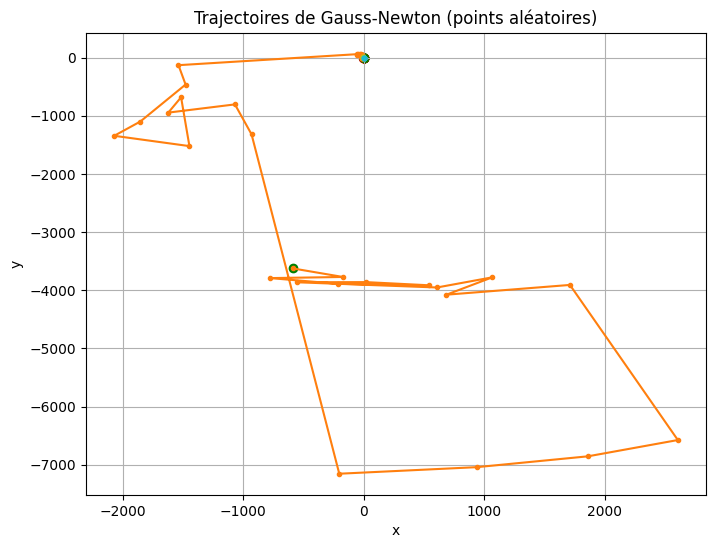

In [5]:
np.random.seed(0)

liste_beta0 = generer_points_aleatoires(10)

tracer_convergence(f, liste_beta0)

In [6]:
def levenberg_marquardt(f, y, p, tol=1e-6, NitMax=1000, lambda_=1e-3):
    t_p = torch.tensor(p, dtype=torch.float64, requires_grad=True)
    t_y = torch.tensor(y, dtype=torch.float64)

    error = torch.linalg.norm(t_y - f(t_p))
    convergence = False

    p_history = [t_p.detach().clone()]
    pas_history = []
    error_history = []
    
    for i in range(NitMax):
        Jr = jacobian(f, t_p)

        with torch.no_grad():
            A = Jr.T @ Jr + lambda_ * torch.diag(torch.diag(Jr.T @ Jr))
            B = Jr.T @ (t_y - f(t_p))

            J = torch.linalg.solve(A, B)
            temp = t_p + J

            new_error = torch.linalg.norm(t_y - f(temp))

            if new_error > error:
                lambda_ *= 2
            else:
                lambda_ /= 2
                t_p = temp.clone()
                error = new_error
                p_history.append(t_p.detach().clone())
                error_history.append(error)
            if torch.linalg.norm(J) < tol or error < tol:
                convergence = True
                break

    return {
    "p": t_p.detach(),
    "iterations": i + 1,
    "convergence": convergence,
    "f_norm": error.item(),
    "norme_du_dernier_pas": torch.linalg.norm(J).item(),
    "lambda_final": lambda_,        
    "p_history": p_history,
    "error_history": error_history  
    }

In [7]:
def Newton(F,JF,x0,Tol=1.e-8,IterMax=100):
    cvg = False
    x = x0.copy()
    for n_it in range(IterMax):
        x -= solve(JF(x),F(x))
        if np.linalg.norm(F(x))<Tol:
            cvg = True
            break
    return x,cvg,n_it

In [8]:
def gf_opt(GradF, v0=np.array([1,1]) , tol=1e-6, NitMax=1000): #Gradient à pas optimal
    iterates = [v0]
    v = v0.copy()
    a = v[0]
    b = v[1]
    
    converged = False
    for n_it in range(NitMax):
        p = fsolve(lambda x: GradF(v)@GradF(v- x*GradF(v)),1)
        v = v- p*GradF(v)
        iterates.append(v)
        if np.linalg.norm(GradF(v))<tol:
            converged = True
            break
    return v, iterates, n_it, converged

def gf_fix(GradF, v0=np.array([1,1]), rho=0.2, tol=1e-6, NitMax=1000): #Gradient à pas fixe
    iterates = [v0]
    v = v0.copy()
    converged = False
    for n_it in range(NitMax):
        v = v- rho*GradF(v)
        iterates.append(v)
        if np.linalg.norm(GradF(v))<tol:
            converged = True
            break
    return v, iterates, n_it, converged

In [9]:
def multilateration(x, lst_pos_dst): # Pour gauss_newton
    
    residus = []
    for ai, di in lst_pos_dst:
        ai_t = torch.tensor(ai, dtype=torch.float64)
        ri = torch.linalg.norm(x - ai_t) - di
        residus.append(ri)
    return torch.stack(residus)

def multilat_lm(x, stations):# fonction créer pour l'algorithme Levenberg-Marquardt
    residus = []
    for ai in stations:
        ai_t = torch.tensor(ai, dtype=torch.float64)
        residus.append(torch.linalg.norm(x - ai_t))
    return torch.stack(residus)

def GradF_multilateration(x, lst_pos_dst): #vrai uniquement dans les cas ou les ai!=x
    grad = np.zeros(len(x))
    for ai, di in lst_pos_dst:
        diff = x - ai
        norm = np.linalg.norm(diff)
        grad += 2 * (norm - di) * (diff / norm)
    return grad

In [10]:
#liste des points et leurs distance à x

stations = np.array([[14,0],[9,-4],[2,3]])# Pour le rendu final créer des stations aléatoire
true_pos = [1,0]
distances_station = generate_trilateration_data(true_pos,stations,noise_std=0)

lst_stations_distance = []

for i in range(stations.shape[0]):
    lst_stations_distance.append([stations[i],distances_station[i]])
    
resultat_gauss_newton = gauss_newton(lambda x : multilateration(x,lst_stations_distance),[1,1])
resultat_lm = levenberg_marquardt(lambda x : multilat_lm(x,stations),distances_station,[1,1])
resultat_gd_fix = gf_fix(lambda x : GradF_multilateration(x,lst_stations_distance),v0=[1,1])
resultat_gd_opt = gf_opt(lambda x : GradF_multilateration(x,lst_stations_distance),v0=[1,1])
lst_result = [ resultat_gauss_newton, resultat_lm, resultat_gd_fix,resultat_gd_opt]

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


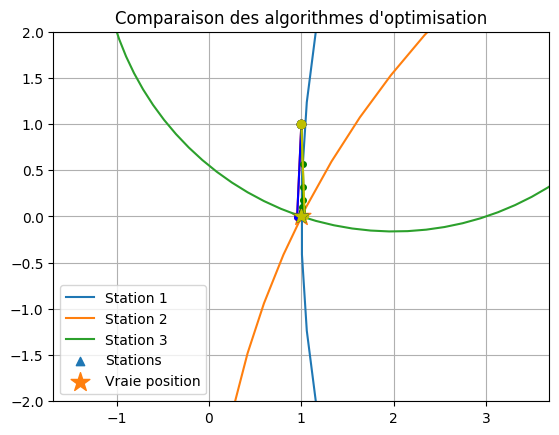

In [11]:
theta = np.linspace(0, 2*np.pi, 100)

for i in range(len(stations)):
    station = stations[i]
    distance = distances_station[i]
    x = station[0] + distance * np.cos(theta)
    y = station[1] + distance * np.sin(theta)
    plt.plot(x, y, label=f"Station {i+1}")

# Afficher les stations et la vraie position
plt.scatter(stations[:,0], stations[:,1], marker='^', label='Stations')
plt.scatter(true_pos[0], true_pos[1], marker='*', s=200, label='Vraie position')
plt.legend()
plt.axis('equal')
plt.grid()
marge = 2  # ajuste selon ce que tu veux voir
plt.xlim(true_pos[0] - marge, true_pos[0] + marge)
plt.ylim(true_pos[1] - marge, true_pos[1] + marge)

beta_gauss = resultat_gauss_newton['beta_history']
beta_gauss = np.array(beta_gauss) 

p_lm = resultat_lm['p_history']
p_lm = np.array(p_lm)
#chemin identique à Gauss_Newton(Voir schéma

_,grad_fix,_,_ = resultat_gd_fix
grad_fix = np.array(grad_fix)
#Plus d'itération chemin moins direct

_,grad_opt,_,_ = resultat_gd_opt
grad_opt = np.array(grad_opt)
#Moins de pas que pas fixe mais ne reste pas optimal

chemins = [
    (beta_gauss, 'r', 'Chemin Gauss-Newton'),
    (p_lm,       'b', 'Chemin Levenberg-Marquardt'),
    (grad_fix,   'g', 'Chemin Gradient Fixe'),
    (grad_opt,   'y', 'Chemin Gradient Optimal'),
]


for chemin, couleur, label in chemins:
    data = np.array(chemin)
    plt.plot(data[:, 0], data[:, 1], f'{couleur}-o', markersize=4, label=label)
    plt.scatter(data[0, 0],  data[0, 1],  c=couleur, zorder=5)  # point départ
    plt.scatter(data[-1, 0], data[-1, 1], c=couleur, zorder=5, marker='*', s=100)

plt.title("Comparaison des algorithmes d'optimisation")
plt.show()

In [12]:
#On réessaie en changeant le point de départ

stations = np.array([[14,0],[9,-4],[2,3]])# Pour le rendu final créer des stations aléatoire
true_pos = [0,1]
distances_station = generate_trilateration_data(true_pos,stations,noise_std=0)

lst_stations_distance = []

for i in range(stations.shape[0]):
    lst_stations_distance.append([stations[i],distances_station[i]])
    
resultat_gauss_newton = gauss_newton(lambda x : multilateration(x,lst_stations_distance),[10,10])
resultat_lm = levenberg_marquardt(lambda x : multilat_lm(x,stations),distances_station,[10,10])
resultat_gd_fix = gf_fix(lambda x : GradF_multilateration(x,lst_stations_distance),v0=[10,10])
resultat_gd_opt = gf_opt(lambda x : GradF_multilateration(x,lst_stations_distance),v0=[10,10])
lst_result = [ resultat_gauss_newton, resultat_lm, resultat_gd_fix,resultat_gd_opt]

/tmp/ipykernel_13230/2177814355.py:9: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  p = fsolve(lambda x: GradF(v)@GradF(v- x*GradF(v)),1)


In [13]:
resultat_gauss_newton['convergence']

True

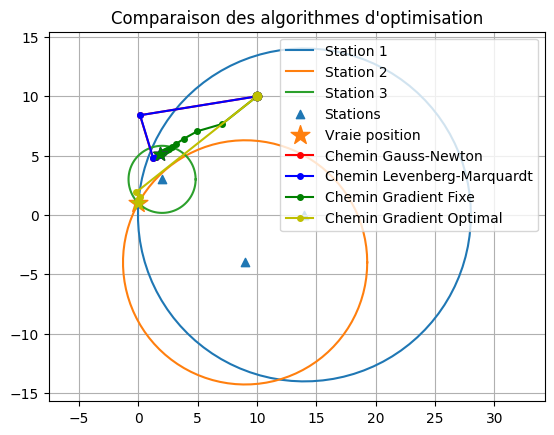

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


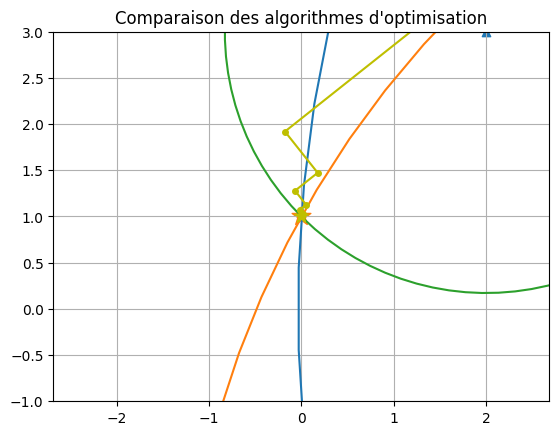

In [14]:
def plot_comparaison(chemins, stations, distances_station, true_pos, xlim=None, ylim=None,legend=True):
    theta = np.linspace(0, 2*np.pi, 100)
    for i in range(len(stations)):
        x = stations[i][0] + distances_station[i] * np.cos(theta)
        y = stations[i][1] + distances_station[i] * np.sin(theta)
        plt.plot(x, y, label=f"Station {i+1}")

    plt.scatter(stations[:,0], stations[:,1], marker='^', label='Stations')
    plt.scatter(true_pos[0], true_pos[1], marker='*', s=200, label='Vraie position')

    for chemin, couleur, label in chemins:
        data = np.array(chemin)
        plt.plot(data[:, 0], data[:, 1], f'{couleur}-o', markersize=4, label=label)
        plt.scatter(data[0, 0],  data[0, 1], c=couleur, zorder=5)
        plt.scatter(data[-1, 0], data[-1, 1], c=couleur, zorder=5, marker='*', s=100)

    plt.gca().set_aspect('equal', adjustable='datalim')
    plt.grid()
    if legend:
        plt.legend(loc='upper right')
    plt.title("Comparaison des algorithmes d'optimisation")
    if xlim: plt.xlim(xlim)
    if ylim: plt.ylim(ylim)
    plt.show()

beta_gauss = resultat_gauss_newton['beta_history']
beta_gauss = np.array(beta_gauss) 

p_lm = resultat_lm['p_history']
p_lm = np.array(p_lm)
#chemin identique à Gauss_Newton(Voir schéma

v_fixe,grad_fix,_,_ = resultat_gd_fix
grad_fix = np.array(grad_fix)
#Plus d'itération chemin moins direct

v_opt,grad_opt,_,_ = resultat_gd_opt
grad_opt = np.array(grad_opt)

chemins = [
    (beta_gauss, 'r', 'Chemin Gauss-Newton'),
    (p_lm,       'b', 'Chemin Levenberg-Marquardt'),
    (grad_fix,   'g', 'Chemin Gradient Fixe'),
    (grad_opt,   'y', 'Chemin Gradient Optimal'),
]

# Vue globale
plot_comparaison(chemins, stations, distances_station, true_pos)

# Vue zoomée
marge = 2
plot_comparaison(chemins, stations, distances_station, true_pos,
                 xlim=(true_pos[0]-marge, true_pos[0]+marge),
                 ylim=(true_pos[1]-marge, true_pos[1]+marge),legend=False)

In [15]:
def plot_multilateration_surface(lst_pos_dst, true_pos, xlim, ylim, resolution=200):
    x = np.linspace(xlim[0], xlim[1], resolution)
    y = np.linspace(ylim[0], ylim[1], resolution)
    X, Y = np.meshgrid(x, y)
    
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            pt = torch.tensor([X[i,j], Y[i,j]], dtype=torch.float64)
            Z[i,j] = torch.sum(multilateration(pt, lst_pos_dst)**2).item()
    
    plt.contourf(X, Y, Z, levels=50, cmap='jet', alpha=0.5)
    plt.colorbar(label='||f(x)||²')

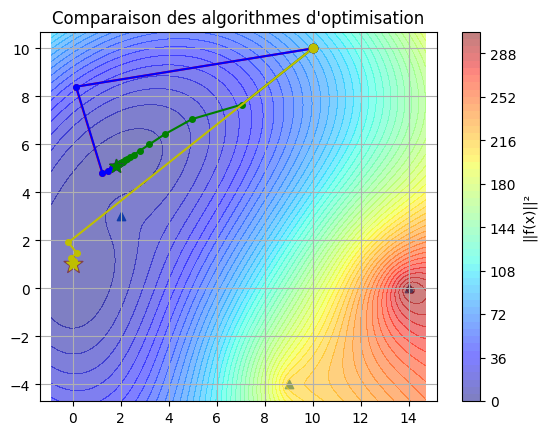

In [16]:
def plot_comparaison_2(chemins, stations, distances_station, true_pos, lst_pos_dst, xlim=None, ylim=None, legend=True):
    
    # Tracer d'abord les chemins pour que matplotlib calcule les limites
    plt.scatter(stations[:,0], stations[:,1], marker='^', label='Stations')
    plt.scatter(true_pos[0], true_pos[1], marker='*', s=200, label='Vraie position')
    for chemin, couleur, label in chemins:
        data = np.array(chemin)
        plt.plot(data[:, 0], data[:, 1], f'{couleur}-o', markersize=4, label=label)
        plt.scatter(data[0, 0],  data[0, 1], c=couleur, zorder=5)
        plt.scatter(data[-1, 0], data[-1, 1], c=couleur, zorder=5, marker='*', s=100)

    # Récupérer les limites automatiques
    ax = plt.gca()
    _xlim = xlim if xlim else ax.get_xlim()
    _ylim = ylim if ylim else ax.get_ylim()

    # Tracer la heatmap sur exactement cette zone
    plot_multilateration_surface(lst_pos_dst, true_pos, xlim=_xlim, ylim=_ylim)

    ax.set_aspect('equal', adjustable='datalim')
    plt.grid()
    if legend:
        plt.legend(loc='upper right')
    plt.title("Comparaison des algorithmes d'optimisation")
    if xlim: plt.xlim(xlim)
    if ylim: plt.ylim(ylim)
    plt.show()


plot_comparaison_2(chemins, stations, distances_station, true_pos,lst_stations_distance,legend=False)

Certain des algorithmes convergent vers un minimum local.

Seul le gradient opitmal converge réelement

In [17]:
print(f'Résultat gauss newton: {resultat_gauss_newton["beta"]}')
print(f'Résultat LM : {resultat_lm["p"]}')
print(f'Résulat grad fixe : {v_fixe}')
print(f'Résultat grad opt : {v_opt}')


Résultat gauss newton: tensor([1.7904, 5.0966], dtype=torch.float64)
Résultat LM : tensor([1.7904, 5.0966], dtype=torch.float64)
Résulat grad fixe : [1.79039785 5.0966247 ]
Résultat grad opt : [-6.24106002e-08  1.00000024e+00]


Expliquons pourquoi cela arrive à l'aide de la question 2

Question 3

In [18]:
#sdp penalisation
def sdp_residuals(beta, lst_pos_dst, epsilon=1e-2):

    m = len(lst_pos_dst)
    n = len(lst_pos_dst[0][0])

    # extraction
    x = beta[:n]
    X = beta[n:].reshape(n, n)

    residuals = []
    for i in range(m):
        ai = torch.tensor(lst_pos_dst[i][0], dtype=torch.float64)
        di = lst_pos_dst[i][1]

        dist_sq = torch.trace(X) - 2 * torch.dot(x, ai) + torch.dot(ai, ai)

        residuals.append(dist_sq - di**2)

    M = torch.block_diag(X, torch.ones(1,1))
    M[:n, n] = x
    M[n, :n] = x

    eigvals = torch.linalg.eigvalsh(M)

    for lam in eigvals:
        residuals.append(torch.sqrt(torch.tensor(1/epsilon)) * torch.relu(-lam))

    return torch.stack(residuals)

In [19]:
stations = np.array([[14,0],[9,-4],[2,3]])# Pour le rendu final créer des stations aléatoire
true_pos = [0,0]
distances_station = generate_trilateration_data(true_pos,stations,noise_std=0)

n = stations.shape[1]

x0 = np.array([10,10])
X0 = np.outer(x0, x0)

beta0 = np.concatenate([x0, X0.flatten()])

lst_pos_dst = [(stations[i], distances[i]) for i in range(len(stations))]

result = gauss_newton(
    f=lambda beta: sdp_residuals(beta, lst_pos_dst, epsilon=1e-2),
    beta0=beta0
)

In [20]:
result

{'beta': tensor([ 8.3659e+00,  5.4712e+00,  4.3056e+01, -4.5044e+20,  8.7684e+00,
          2.5340e+01], dtype=torch.float64),
 'iterations': 1000,
 'convergence': False,
 'norme_du_dernier_pas': 50.227647933648925,
 'f_norm': 11.693261575915447,
 'jacobian_final': array([[-28.        ,   0.        ,   1.        ,   0.        ,
           0.        ,   1.        ],
        [-18.        ,   8.        ,   1.        ,   0.        ,
           0.        ,   1.        ],
        [ -4.        ,  -6.        ,   1.        ,   0.        ,
           0.        ,   1.        ],
        [  3.02518769,   2.93483457,  -0.23997253,  -0.23280528,
          -0.23280528,  -0.2258521 ],
        [  0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ],
        [  0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ]]),
 'normal_matrix_final': array([[ 1.13315176e+03, -1.11121575e+02, -5.07259619e+01,
         -7.04279664e-01, -7.042

In [21]:
# Nouvelle approche ( on en a parlé avec le prof)
# Ne marche pas non plus
def project_psd(M):
    eigvals, eigvecs = np.linalg.eigh(M)
    eigvals = np.maximum(eigvals, 0)
    return eigvecs @ np.diag(eigvals) @ eigvecs.T

def extract_x_X(M):
    n = M.shape[0] - 1
    X = M[:n, :n]
    x = M[:n, n]
    return x, X

def compute_gradient(x, X, lst_pos_dst):
    n = len(x)
    
    grad_x = np.zeros(n)
    grad_X = np.zeros((n, n))
    
    for ai, di in lst_pos_dst:
        dist_sq = np.trace(X) - 2*np.dot(x, ai) + np.dot(ai, ai)
        r = dist_sq - di**2 ## Minimiser sur (ri**2 -di**2)**2 identique à (ri -di)**2 car ri = di => ri² = di²
         
        # gradient par rapport à x
        grad_x += 2 * r * (-2 * ai)
        
        # gradient par rapport à X
        grad_X += 2 * r * np.eye(n)
    
    return [grad_x, grad_X]
    
def projected_gradient_sdp(lst_pos_dst, x, X,
                           max_iter=500, 
                           step=1e-3, 
                           tol=1e-6):
    
    history = []
    converged = False
    for k in range(max_iter):
        
        grad_x, grad_X = compute_gradient(x, X, lst_pos_dst)
        
        #descente
        x_new = x - step * grad_x
        X_new = X - step * grad_X
        
        #projection SDP
        M = np.block([
            [X_new, x_new.reshape(-1,1)],
            [x_new.reshape(1,-1), np.array([[1]])]
        ])
        
        M = project_psd(M)
        
        x_new, X_new = extract_x_X(M)
        
        #critère d'arrêt
        if np.linalg.norm(x_new - x) < tol:
            converged = True
            break
        
        x, X = x_new, X_new
        history.append(x.copy())

    return x, history,k,converged

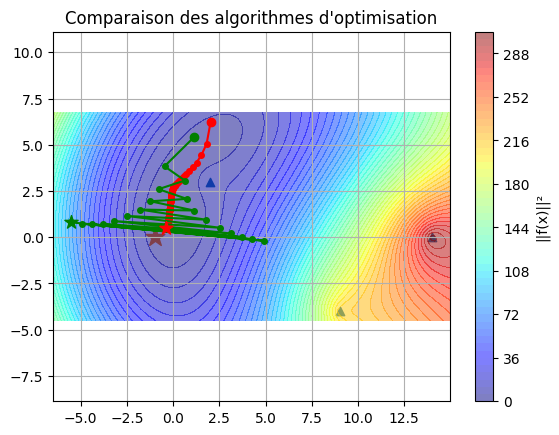

In [22]:
stations = np.array([[14,0],[9,-4],[2,3]])
true_pos = np.array([-1,0])

distances = generate_trilateration_data(true_pos, stations, noise_std=0)

lst_pos_dst = [(stations[i], distances[i]) for i in range(len(stations))]

x = np.array([1,10])
X = np.array([[5,5],[5,5]])

x_est, hist,k,converged   = projected_gradient_sdp(lst_pos_dst,x,X,step =1e-4)
x_est2,hist2,k,converged2 = projected_gradient_sdp(lst_pos_dst,x,X,step=1e-3)
n_hist=20
plot_comparaison_2([(hist, 'r', 'Chemin GP step =1e-6 '),(hist2[:n_hist], 'g', 'Chemin GP step =1e-6 ')],
                   stations, distances_station, true_pos,lst_stations_distance,legend=False)

In [23]:
def pas_optimal(x, X, gradient):
    grad_x, grad_X = gradient(x, X)
    
    # Il faut chercher un scalaire t tel que : ∇f(x - t·∇f)·∇f = 0
    def condition(t):
        t = t[0]
        gx, gX = gradient(x - t * grad_x, X - t * grad_X)
        # produit scalaire entre gradient courant et direction de descente
        return [gx @ grad_x + np.sum(gX * grad_X)]
    
    result = fsolve(condition, x0=[1e-3])
    t_opt = result[0]
    return t_opt 

In [24]:
# On va réessayer mes avec un algorithme de pas optimal
def projected_gradient_sdp_opt(lst_pos_dst, x, X,
                           max_iter=1000, 
                           tol=1e-6):
    
    history = [x.copy()]
    converged = False
    for k in range(max_iter):
        
        # --- gradient ---
        grad_x, grad_X = compute_gradient(x, X, lst_pos_dst)
        # --- descente ---
        step_opt = pas_optimal(x,X,lambda v1,v2 : compute_gradient(v1,v2,lst_pos_dst))
        x_new = x - step_opt * grad_x
        X_new = X - step_opt * grad_X
        
        # --- projection SDP ---
        M = np.block([
            [X_new, x_new.reshape(-1,1)],
            [x_new.reshape(1,-1), np.array([[1]])]
        ])
        
        M = project_psd(M)
        
        x_new, X_new = extract_x_X(M)
        
        # --- critère d'arrêt ---
        if np.linalg.norm(x_new - x) < tol:
            converged = True
            break
        
        x, X = x_new, X_new
        history.append(x.copy())

    return x,history,k, converged

/tmp/ipykernel_13230/500353528.py:11: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  result = fsolve(condition, x0=[1e-3])


Estimation: [-0.99174601  0.00605405]


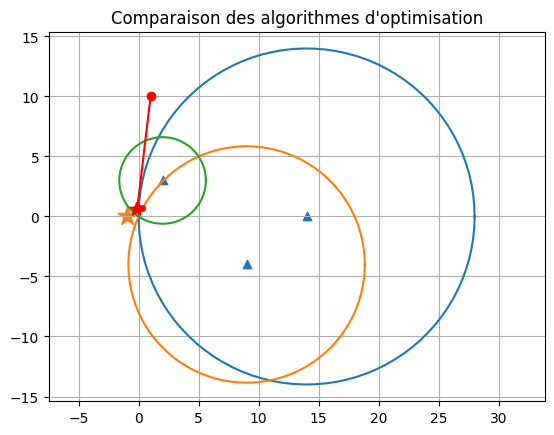

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


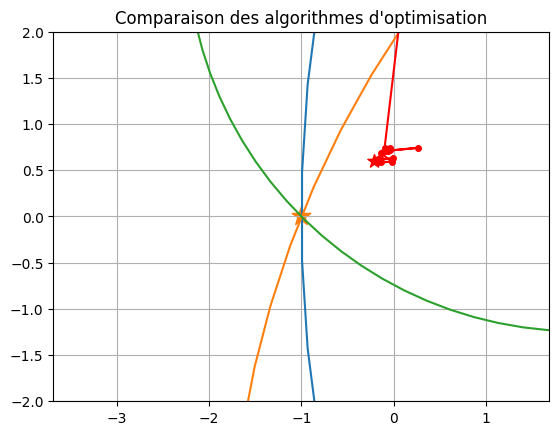

In [25]:
stations = np.array([[14,0],[9,-4],[2,3]])
true_pos = np.array([-1,0])

distances = generate_trilateration_data(true_pos, stations, noise_std=0)

lst_pos_dst = [(stations[i], distances[i]) for i in range(len(stations))]

x = np.array([1,10])
X = np.array([[10,10],[10,10]])

x_est, hist,k,conv = projected_gradient_sdp_opt(lst_pos_dst,x,X)
print("Estimation:", x_est)
n_hist = 20
plot_comparaison([(hist[:n_hist], 'r', 'Chemin GP step =1e-6 ')],
                   stations, distances_station, true_pos,legend=False)
plot_comparaison([(hist[:n_hist], 'r', 'Chemin GP step =1e-6 ')], stations, distances, true_pos,
                 xlim=(true_pos[0]-marge, true_pos[0]+marge),
                 ylim=(true_pos[1]-marge, true_pos[1]+marge),legend=False)

S'approche du résultat sans jamais l'atteindre

Question 4 :

Test des algorithmes sur différents positionnement de stations avec des bruits différents

In [26]:
# On va commencer par créer une variable ou on pourra parcourir différent bruit
bruits = np.linspace(0.01,2,20)

In [27]:
def comparaison_pos_station(true_pos,stations,bruit=0,plot=True):
    distances = generate_trilateration_data(true_pos, stations, noise_std=bruit)

    lst_pos_dst = [(stations[i], distances[i]) for i in range(len(stations))]
    p_initial = np.array([10,10])
    X = np.array([[10,10],[10,10]])
    
    resultat_gauss_newton = gauss_newton(lambda x : multilateration(x,lst_pos_dst),p_initial)
    resultat_lm = levenberg_marquardt(lambda x : multilat_lm(x,stations),distances,p_initial)
    resultat_gd_fix = gf_fix(lambda x : GradF_multilateration(x,lst_pos_dst),v0=p_initial)
    resultat_gd_opt = gf_opt(lambda x : GradF_multilateration(x,lst_pos_dst),v0=p_initial)
    resultat_proj_grad_opt = projected_gradient_sdp_opt(lst_pos_dst,p_initial,X)
    lst_result = [ resultat_gauss_newton, resultat_lm, resultat_gd_fix,resultat_gd_opt,resultat_proj_grad_opt]
    
    beta_gauss = resultat_gauss_newton['beta_history']
    beta_gauss = np.array(beta_gauss) 
    est_beta = resultat_gauss_newton['beta']
    
    p_lm = resultat_lm['p_history']
    p_lm = np.array(p_lm)
    est_lm = resultat_lm['p']
    
    v_fixe,grad_fix,_,_ = resultat_gd_fix
    grad_fix = np.array(grad_fix)
    
    v_opt,grad_opt,_,_ = resultat_gd_opt
    grad_opt = np.array(grad_opt)
    
    pv_opt,hist_popt,_,_ = resultat_proj_grad_opt
    
    chemins = [
        (beta_gauss, 'r', 'Chemin Gauss-Newton'),
        (p_lm,       'b', 'Chemin Levenberg-Marquardt'),
        (grad_fix,   'g', 'Chemin Gradient Fixe'),
        (grad_opt,   'y', 'Chemin Gradient Optimal'),
        (hist_popt,  'c', 'Chemin Gradient Projete Optimal')
    ]
    if plot:
        plot_comparaison_2(chemins, stations, distances, true_pos,lst_pos_dst,legend = False)
    
        # Vue zoomée
        marge = 2
        plot_comparaison(chemins, stations, distances, true_pos,
                         xlim=(true_pos[0]-marge, true_pos[0]+marge),
                         ylim=(true_pos[1]-marge, true_pos[1]+marge),legend=False)
    return [est_beta.detach().numpy(),est_lm.detach().numpy(),v_fixe,v_opt,pv_opt], chemins

def plot_bruit_comparaison(true_pos,result,list_bruit):

    
    graphe_gauss = [ np.linalg.norm(true_pos-est[0]) for est in result]
    graphe_lm    = [ np.linalg.norm(true_pos-est[1]) for est in result]
    graphe_gf    = [ np.linalg.norm(true_pos-est[2]) for est in result]
    graphe_gopt  = [ np.linalg.norm(true_pos-est[3]) for est in result]
    graphe_gpopt = [ np.linalg.norm(true_pos-est[4]) for est in result]
    
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))

    axes[0, 0].plot(list_bruit, graphe_gauss)
    axes[0, 0].set_title("Estimation Gauss-Newton/Bruit")
    
    axes[0, 1].plot(list_bruit, graphe_lm)
    axes[0, 1].set_title("Estimation Levenberg-Marquardt/Bruit")
    
    axes[0, 2].plot(list_bruit, graphe_gf)
    axes[0, 2].set_title("Estimation Gradient Pas Fixe/Bruit")
    
    axes[1, 0].plot(list_bruit, graphe_gopt, color='red')
    axes[1, 0].set_title("Estimation Gradient Pas Opt/Bruit")
    
    axes[1, 1].plot(list_bruit, graphe_gpopt, color='green')
    axes[1, 1].set_title("Estimation Gradient Pas Opt Projeté/Bruit")
    
    axes[1, 2].set_visible(False)
    
    plt.tight_layout()

Première approche par stations correctement répartie

/tmp/ipykernel_13230/2177814355.py:9: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  p = fsolve(lambda x: GradF(v)@GradF(v- x*GradF(v)),1)


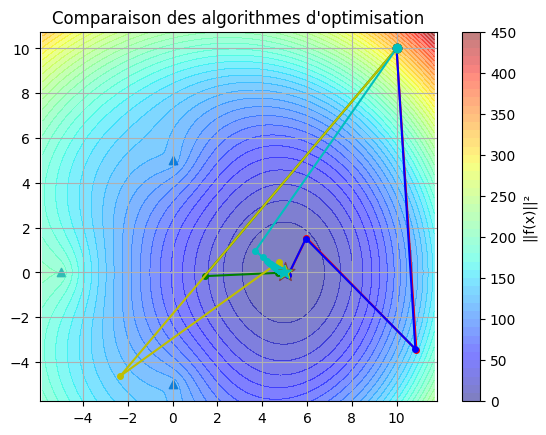

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


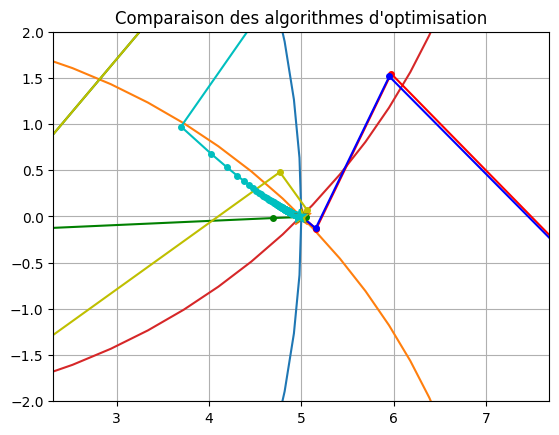

In [28]:
stations = np.array([[-5,0],[0,-5],[5,0],[0,5]])
true_pos = np.array([5,0])
result = comparaison_pos_station(true_pos,stations)

Prédit comme attendu lors de nos test plus haut

Etudions la précision des predictions lorsqu'on rajoute du bruit

In [29]:
result_station_repartie = [comparaison_pos_station(true_pos,stations,plot=False,bruit = bruit)[0]
                           for bruit in bruits]

/tmp/ipykernel_13230/2177814355.py:9: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  p = fsolve(lambda x: GradF(v)@GradF(v- x*GradF(v)),1)
/tmp/ipykernel_13230/2177814355.py:9: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  p = fsolve(lambda x: GradF(v)@GradF(v- x*GradF(v)),1)
/tmp/ipykernel_13230/500353528.py:11: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  result = fsolve(condition, x0=[1e-3])


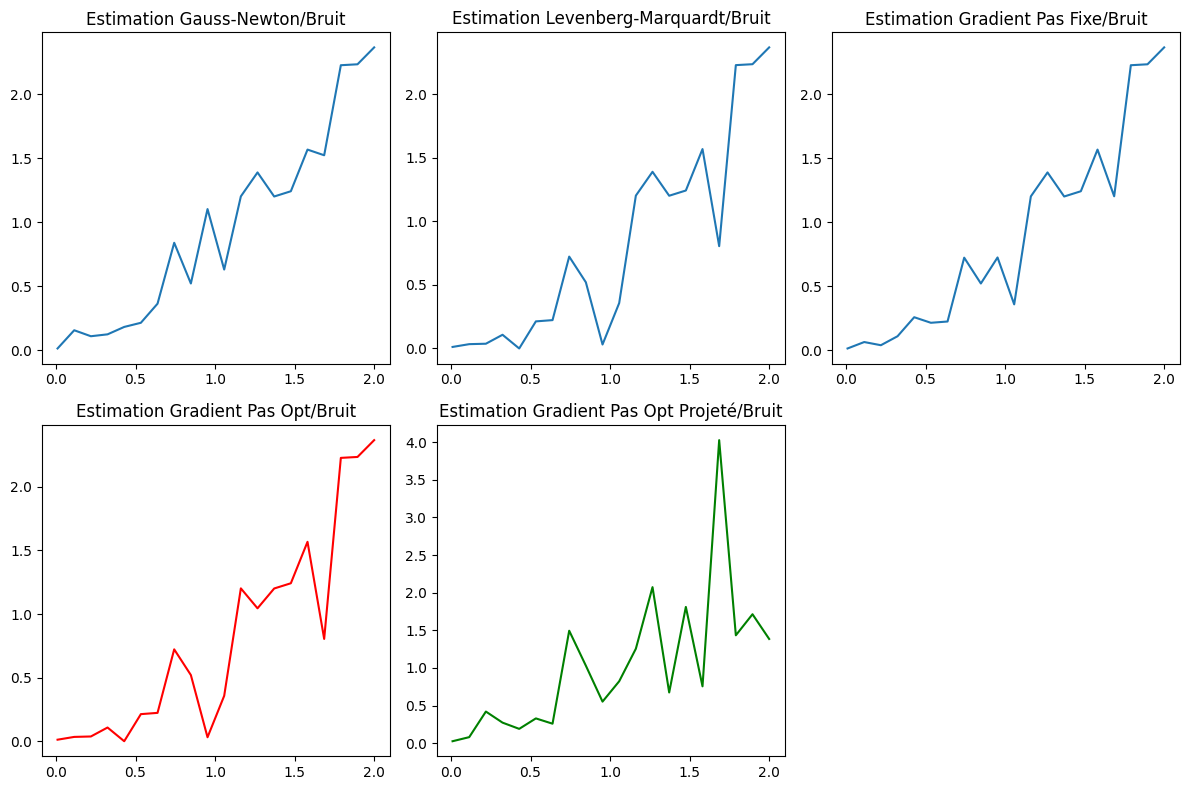

In [30]:
plot_bruit_comparaison(true_pos,result_station_repartie,bruits)

Les différents algo réagissent de la meme façon avec le bruit. Avec une croissance de l'erreur si le bruit est élevé

Comparaison avec des stations alignés

/tmp/ipykernel_13230/2177814355.py:9: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  p = fsolve(lambda x: GradF(v)@GradF(v- x*GradF(v)),1)


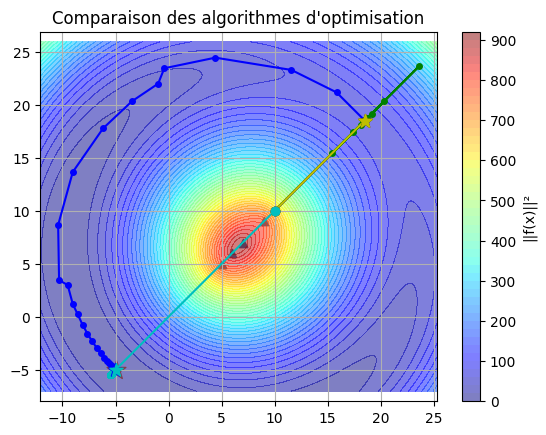

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


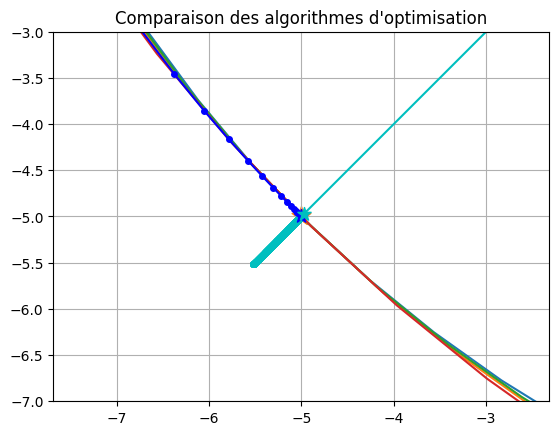

In [31]:
stations = np.array([[5,5],[7,7],[6,6],[9,9]])
true_pos = np.array([-5,-5])
result = comparaison_pos_station(true_pos,stations)

/tmp/ipykernel_13230/500353528.py:11: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  result = fsolve(condition, x0=[1e-3])


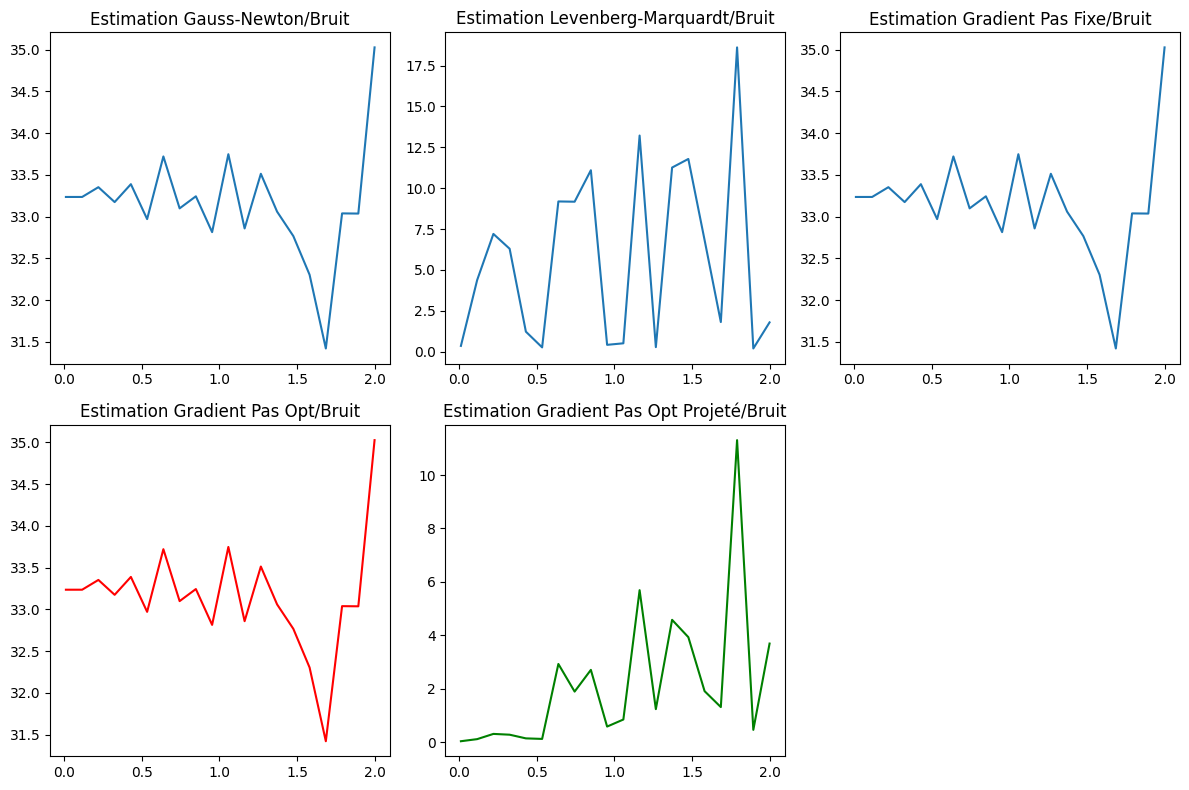

In [32]:
result_stations_alignes = [comparaison_pos_station(true_pos,stations,plot=False,bruit = bruit)[0]
                           for bruit in bruits]
plot_bruit_comparaison(true_pos,result_stations_alignes,bruits)

Algorithme de descente non projeté avec une erreur très élévé comparé aux autres algorithmes. Gradient projeté obtiens une erreur largement meilleurs que les autres algo

Stations regroupé autour d'un même secteur

/tmp/ipykernel_13230/500353528.py:11: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  result = fsolve(condition, x0=[1e-3])


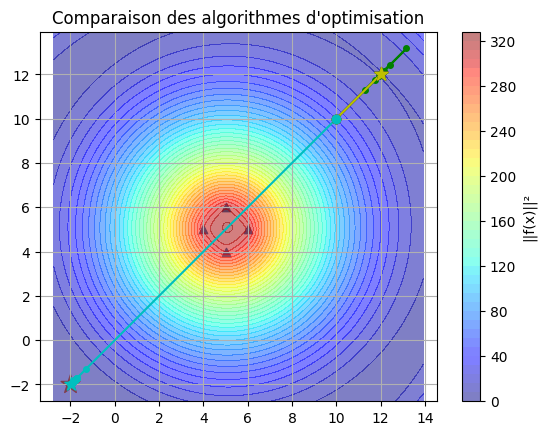

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


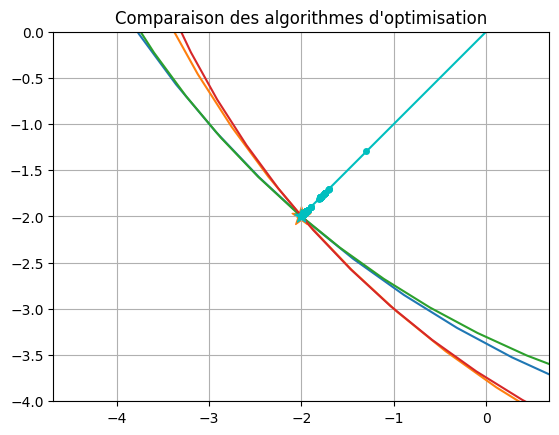

In [33]:
stations = np.array([[5,6],[6,5],[4,5],[5,4]])
true_pos = np.array([-2,-2])
result = comparaison_pos_station(true_pos,stations)

/tmp/ipykernel_13230/2177814355.py:9: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  p = fsolve(lambda x: GradF(v)@GradF(v- x*GradF(v)),1)
/tmp/ipykernel_13230/500353528.py:11: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  result = fsolve(condition, x0=[1e-3])
/tmp/ipykernel_13230/2177814355.py:9: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  p = fsolve(lambda x: GradF(v)@GradF(v- x*GradF(v)),1)


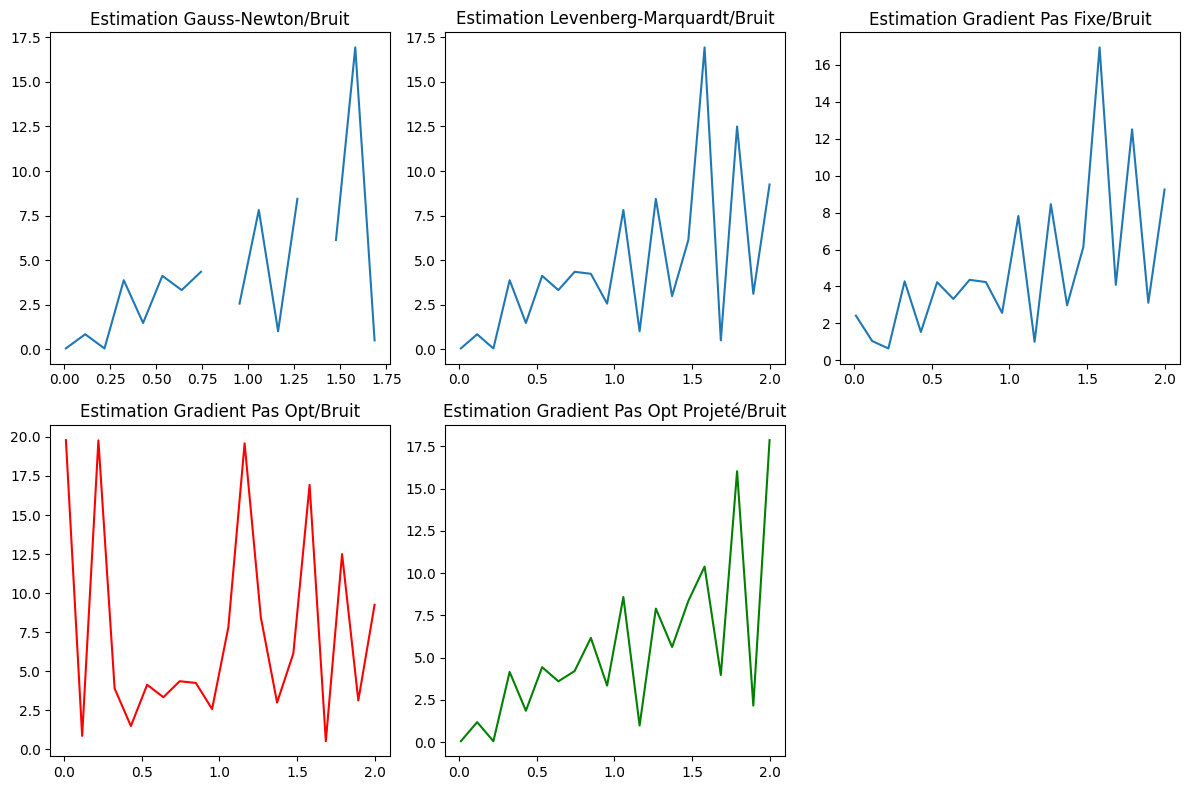

In [34]:
result_stations_secteur = [comparaison_pos_station(true_pos,stations,plot=False,bruit = bruit)[0]
                           for bruit in bruits]
plot_bruit_comparaison(true_pos,result_stations_secteur,bruits)

Question 5:

On se retrouve dans le cas ou di = c*τi - b

Où c est la vitesse de la lumière, temps d’arrivée τi et b une nouvelle inconnue que l'on souhaite trouver

In [35]:
def multilateration_gps(v, lst_pos_dst):
    # v = [x0, x1, b] — tout dans un seul vecteur 1D
    x = v[:-1]   # position
    b = v[-1]    # biais d'horloge
    
    residus = []
    for ai, di in lst_pos_dst:
        ai_t = torch.tensor(ai, dtype=torch.float64)
        ri = torch.linalg.norm(x - ai_t) + b - di
        residus.append(ri)
    return torch.stack(residus)

def multilat_lm_gps(v, stations):
    x = v[:-1]   # position
    b = v[-1]    # biais d'horloge
    residus = []
    for ai in stations:
        ai_t = torch.tensor(ai, dtype=torch.float64)
        residus.append(torch.linalg.norm(x - ai_t) + b)
    return torch.stack(residus)
    
def GradF_multilateration_gps(v, lst_pos_dst): # Gradient par rapport à x,b
    x = v[:-1]
    b = v[-1]
    grad_x = np.zeros(len(x))
    grad_b = 0.0
    for ai, di in lst_pos_dst:
        diff = x - ai
        norm = np.linalg.norm(diff)
        ri = norm + b - di        # résidu avec biais
        grad_x += 2 * ri * (diff / norm)
        grad_b += 2 * ri          # dérivée par rapport à b
    return np.append(grad_x, grad_b)

In [36]:
stations = np.array([[14, 0], [9, -4], [2, 3]])
true_pos = [1, 0]
horloge_bias = 5

distances_station = generate_gps_pseudoranges(true_pos, stations, true_bias=horloge_bias, noise_std=0)

lst_stations_distance = []
for i in range(stations.shape[0]):
    lst_stations_distance.append([stations[i], distances_station[i]])

resultat = gauss_newton(
    lambda v: multilateration_gps(v, lst_stations_distance),
    [1, 1, 20]
)

beta = resultat["beta"]
print(f"Position estimée : {beta[:2].numpy()}")
print(f"Biais estimé     : {beta[2].item():.4f}")

Position estimée : [1.00000000e+00 5.26531636e-16]
Biais estimé     : 5.0000


Converge correctement proche du point initial

In [37]:
resultat = gauss_newton(
    lambda v: multilateration_gps(v, lst_stations_distance),
    [1, 10, 20]
)

beta = resultat["beta"]
print(f"Position estimée : {beta[:2].numpy()}")
print(f"Biais estimé     : {beta[2].item():.4f}")

Position estimée : [-5288061.75820384 -1051259.07520934]
Biais estimé     : -5391538.3777


Mauvais des qu'on s'éloigne

In [38]:
stations = np.array([[14, 0], [9, -4], [2, 3]])
true_pos = [1, 0]
horloge_bias = 5

distances_station = generate_gps_pseudoranges(true_pos, stations, true_bias=horloge_bias, noise_std=0)

lst_stations_distance = []
for i in range(stations.shape[0]):
    lst_stations_distance.append([stations[i], distances_station[i]])

resultat_lm = levenberg_marquardt(lambda x : multilat_lm_gps(x,stations),
                                  distances_station,[1,1,20])


resultat_lm['p']

tensor([1.0000e+00, 7.7304e-08, 5.0000e+00], dtype=torch.float64)

In [39]:
resultat_lm = levenberg_marquardt(lambda x : multilat_lm_gps(x,stations),
                                  distances_station,[1,10,20])
resultat_lm['p']

tensor([1.0000e+00, 4.9883e-08, 5.0000e+00], dtype=torch.float64)

In [40]:
resultat_lm = levenberg_marquardt(lambda x : multilat_lm_gps(x,stations),
                                  distances_station,[20,10,20])
resultat_lm['p']

tensor([1.0000e+00, 1.9399e-07, 5.0000e+00], dtype=torch.float64)

Beaucoup plus robuste en fonction du choix du point initial

In [41]:
rfix,_,_,_=resultat_gd_fix = gf_fix(lambda x : GradF_multilateration_gps(x,lst_stations_distance),v0=[1,1,4])
ropt,_,_,_= gf_opt(lambda x : GradF_multilateration_gps(x,lst_stations_distance),v0=[1,1,20])
print(rfix)
print(ropt)

/tmp/ipykernel_13230/2177814355.py:9: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  p = fsolve(lambda x: GradF(v)@GradF(v- x*GradF(v)),1)
/tmp/ipykernel_13230/2177814355.py:9: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  p = fsolve(lambda x: GradF(v)@GradF(v- x*GradF(v)),1)


[ 9.99987443e-01 -6.01993981e-06  4.99998964e+00]
[-1.78141274 -1.04063406  2.51349719]


In [42]:
rfix,_,_,_=resultat_gd_fix = gf_fix(lambda x : GradF_multilateration_gps(x,lst_stations_distance),v0=[1,10,20])
ropt,_,_,_= gf_opt(lambda x : GradF_multilateration_gps(x,lst_stations_distance),v0=[1,10,20])
print(rfix)
print(ropt)

/tmp/ipykernel_13230/2177814355.py:9: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  p = fsolve(lambda x: GradF(v)@GradF(v- x*GradF(v)),1)
/tmp/ipykernel_13230/2177814355.py:9: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  p = fsolve(lambda x: GradF(v)@GradF(v- x*GradF(v)),1)


[1.00001263e+00 6.05419430e-06 5.00001042e+00]
[-43.42018081 -10.04202141 -39.40227819]


In [43]:
rfix,_,_,_=resultat_gd_fix = gf_fix(lambda x : GradF_multilateration_gps(x,lst_stations_distance),v0=[20,10,20])
ropt,_,_,_= gf_opt(lambda x : GradF_multilateration_gps(x,lst_stations_distance),v0=[20,10,20])
print(rfix)
print(ropt)

/tmp/ipykernel_13230/2177814355.py:9: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  p = fsolve(lambda x: GradF(v)@GradF(v- x*GradF(v)),1)


[1.00001257e+00 6.02473803e-06 5.00001037e+00]
[-42.38239897  -9.75667509 -38.33297708]


Descente de gradient à pas fixe meilleure que descente de gradient à pas optimal.
Pas fixe pas très sensible au point de départ mais moins précis que Levenberg-Marquardt

Essayons de l'appliquer avec sdp

In [46]:
def compute_gradient_gps(x, X,b, lst_pos_dst):
    n = len(x)
    
    grad_x = np.zeros(n)
    grad_X = np.zeros((n, n))
    grad_b = 0
    for ai, di in lst_pos_dst:
        dist_sq = np.trace(X) - 2*np.dot(x, ai) + np.dot(ai, ai)
        r = dist_sq - (di-b)**2 ## Minimiser sur (ri**2 -di**2)**2 identique à (ri -di)**2 car ri = di => ri² = di²
        
        # gradient par rapport à x
        grad_x += 2 * r * (-2 * ai)
        
        # gradient par rapport à X
        grad_X += 2 * r * np.eye(n)
        
        # gradient par rapport à b
        grad_b += 2*r * 2*(di-b)
    return [grad_x, grad_X,grad_b]
    
def projected_gradient_sdp_gps(lst_pos_dst, x, X, b,
                           max_iter=500, 
                           step=1e-3, 
                           tol=1e-6):
    
    history = []
    converged = False
    for k in range(max_iter):
        
        grad_x, grad_X, grad_b = compute_gradient_gps(x, X, b, lst_pos_dst)
        
        # descente
        x_new = x - step * grad_x
        X_new = X - step * grad_X
        b_new = b - step * grad_b
        
        # projection SDP
        M = np.block([
            [X_new, x_new.reshape(-1,1)],
            [x_new.reshape(1,-1), np.array([[1]])]
        ])
        
        M = project_psd(M)
        x_new, X_new = extract_x_X(M)
        
        # critère d'arrêt
        if np.linalg.norm(x_new - x) < tol:
            converged = True
            break
        
        x, X, b = x_new, X_new, b_new
        history.append(x.copy())
    
    return x, b, history, k, converged

In [47]:

x = np.array([1,10])
X = np.array([[5,5],[5,5]])
b = 20

x_est,b, hist,k,converged   = projected_gradient_sdp_gps(lst_pos_dst,x,X,b,step =1e-4,max_iter=1500)
print(x_est)
print(b)

[4.05200073 0.61504106]
4.664909664792614


Approche toujours mal

Essayons de nouveau Gradient projeté optimal

In [48]:
def pas_optimal_gps(x, X,b, gradient):
    grad_x, grad_X,grad_b = gradient(x, X,b)
    
    # Il faut chercher un scalaire t tel que : ∇f(x - t·∇f)·∇f = 0
    def condition(t):
        t = t[0]
        gx, gX,gb = gradient(x - t * grad_x, X - t * grad_X,b - t *grad_b)
        # produit scalaire entre gradient courant et direction de descente
        return [gx @ grad_x + np.sum(gX * grad_X) + gb*grad_b]
    
    result = fsolve(condition, x0=[1e-3])
    t_opt = result[0]
    return max(t_opt, 1e-6)#evite pas nul ou neg

In [49]:
def projected_gradient_sdp_opt_gps(lst_pos_dst, x, X,b,
                           max_iter=1000, 
                           tol=1e-6):
    
    history = [x.copy()]
    converged = False
    for k in range(max_iter):
        

        grad_x, grad_X,grad_b = compute_gradient_gps(x, X,b, lst_pos_dst)
 
        step_opt = pas_optimal_gps(x,X,b,lambda v1,v2,v3 : compute_gradient_gps(v1,v2,v3,lst_pos_dst))
        x_new = x - step_opt * grad_x
        X_new = X - step_opt * grad_X
        b_new = b - step_opt * grad_b
 
        M = np.block([
            [X_new, x_new.reshape(-1,1)],
            [x_new.reshape(1,-1), np.array([[1]])]
        ])
        
        M = project_psd(M)
        
        x_new, X_new = extract_x_X(M)
        
 
        if np.linalg.norm(x_new - x) < tol:
            converged = True
            break
        
        x, X, b = x_new, X_new,b_new
        history.append(x.copy())

    return x,b,history,k, converged

In [50]:
x_est,b, hist,k,converged   = projected_gradient_sdp_opt_gps(lst_pos_dst,x,X,b,max_iter=1500)

/tmp/ipykernel_13230/144106949.py:11: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  result = fsolve(condition, x0=[1e-3])


In [51]:
x_est,b

(array([-2.44612502,  0.08054371]), np.float64(-1.63930716538569))

Approche aussi mal